# Exercises for Section 3.7 Inventory of statistical tests

This notebook contains the exercises
from [Section 3.7 Inventory of statistical tests]()
in the **No Bullshit Guide to Statistics**.

### Notebook setup

In [1]:
# Ensure required Python modules are installed
%pip install --quiet numpy scipy seaborn pandas ministats

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Figures setup
plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={"figure.figsize": (6, 1.6)},
)
%config InlineBackend.figure_format = "retina"

<Figure size 640x480 with 0 Axes>

In [4]:
# Simplified int and float __repr__
np.set_printoptions(legacy="1.25")

In [5]:
# Download datasets/ directory if necessary
from ministats import ensure_datasets
ensure_datasets()

datasets/ directory already exists.


$\def\stderr#1{\mathbf{se}_{#1}}$
$\def\stderrhat#1{\hat{\mathbf{se}}_{#1}}$
$\newcommand{\Mean}{\textbf{Mean}}$
$\newcommand{\Var}{\textbf{Var}}$
$\newcommand{\Std}{\textbf{Std}}$
$\newcommand{\Freq}{\textbf{Freq}}$
$\newcommand{\RelFreq}{\textbf{RelFreq}}$
$\newcommand{\DMeans}{\textbf{DMeans}}$
$\newcommand{\Prop}{\textbf{Prop}}$
$\newcommand{\DProps}{\textbf{DProps}}$
$$
\newcommand{\CI}[1]{\textbf{CI}_{#1}}
\newcommand{\CIL}[1]{\textbf{L}_{#1}}
\newcommand{\CIU}[1]{\textbf{U}_{#1}}
\newcommand{\ci}[1]{\textbf{ci}_{#1}}
\newcommand{\cil}[1]{\textbf{l}_{#1}}
\newcommand{\ciu}[1]{\textbf{u}_{#1}}
$$
(this cell contains the macro definitions like $\stderr{\overline{\mathbf{x}}}$, $\stderrhat{}$, $\Mean$, ...)

## Exercises

### E3.49

<!-- {exercise:choose-test-given-scenario} -->

See PDF

### E3.50

<!-- {exercise:choose-test-in-nonnormal-scenario} -->



### E3.51

<!-- {exercise:simulation-test-fraud-detection} -->

follows a $\Pois(2)$ distribution, independently across days.
The largest count in last 30 days is nine.


### E3.52 

<!-- {exercise:exercise-TOST-iqs2} -->

Equivalence test for IQ scores.



In [14]:
# Load the IQs dataset and select the two groups
iqs2 = pd.read_csv("datasets/iqs2.csv")
treated = iqs2[iqs2["group"]=="treat"]["iq"]
controls = iqs2[iqs2["group"]=="ctrl"]["iq"]

#### Upper-bound one-sided test

We can implement the 
$$
    H_0^+: \Delta \geq \Delta_{\text{min}}
    \qquad \text{and} \qquad 
    H_A^+: \Delta < \Delta_{\text{min}}.
$$

To perform this test,
we can use the function `ttest_ind`
to compare the `treated` data shifted to the left by $\Delta_{\text{min}} =$ `sesoi`,
and the `controls` data.

In [15]:
# c) Perform a left-tailed hypothesis test
sesoi = 4  # = Δ_min

# Use `ttest_ind` to perform left-tailed Welch t-test
# comparing `treated - sesoi`  and   `controls`:
from scipy.stats import ttest_ind
...

Ellipsis

#### Lower-bound one-sided test

$$
    H_0^-: \Delta \leq -\Delta_{\text{min}}
    \qquad \text{and} \qquad 
    H_A^-: \Delta > -\Delta_{\text{min}}.
$$

To perform this test,
we can use `ttest_ind` comparing `treated+sesoi` and `controls`.

In [17]:
# d) Perform a right-tailed hypothesis test
from scipy.stats import ttest_ind
...

Ellipsis

In [18]:
# d) Perform a right-tailed hypothesis test
res_minus = ttest_ind(treated + sesoi, controls,
                      equal_var=False, alternative="greater")
print("t- =", res_minus.statistic, "  p- =", res_minus.pvalue)

t- = 5.787659026644264   p- = 1.2128566126183658e-07


In [19]:
# e) Take the largest of the two p-values
...

Ellipsis

In [21]:
# f) Use the function `ttost_ind` to perform the TOST procedure
from statsmodels.stats.weightstats import ttost_ind
...

Ellipsis

### E3.53

<!-- {exercise:paired-test-bplong} -->



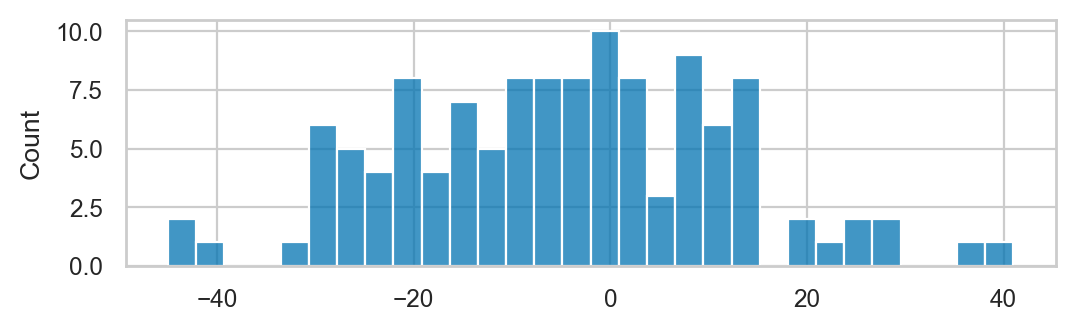

In [25]:
sns.histplot(ds, bins=30);

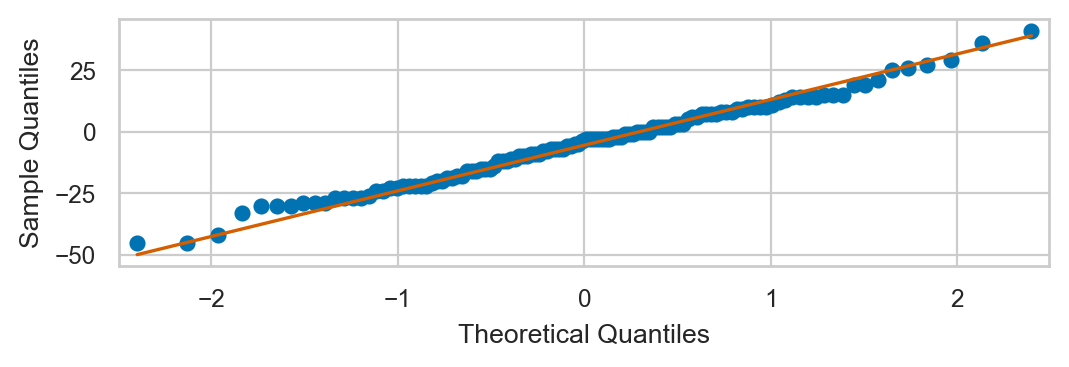

In [26]:
from statsmodels.graphics.api import qqplot
qqplot(ds, line="q");

In [28]:
dbar = ds.mean()
dbar

-5.091666666666667

In [29]:
dstd = np.std(ds, ddof=1)
dstd

16.713601281205523